<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 6: Hierarchical Attention.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 11/04/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                             # library for numerical operations.
import matplotlib.pyplot as plt                # library for plotting.
import matplotlib as mpl                       # library for plotting.
import torch                                   # library for tensor operations.
from nltk.tokenize import TweetTokenizer       # library for tweet tokenization.
from nltk.corpus import stopwords              # library for stopwords.
stopwords_es = set(stopwords.words('spanish')) # set of spanish stopwords.
import os                                      # library for operating system.
import time                                    # library for time.
from typing import Tuple, Callable, List       # library for typing.
import random                                  # library for random numbers.
import pandas as pd                            # library for data manipulation.
from collections import defaultdict, Counter   # library for collections.
from tqdm import tqdm                          # library for progress bar.
import torch.nn as nn                          # library for neural network operations.
import torch.nn.functional as F                # library for functional operations.
from torch.utils.data import (DataLoader,      # library for data loading.
                              Dataset)         # library for dataset.
from sklearn.metrics import (confusion_matrix,      # library for evaluation.
                             classification_report, # library for evaluation.
                             f1_score)              # library for evaluation.
from torch import optim                        # for neural networks.
from colorama import Fore, Style               # library for colored text.
import seaborn as sns                          # library for data visualization.
sns.set_style("darkgrid")                      # set style for seaborn.
import xml.etree.ElementTree as ET             # library for xml parsing.
from IPython.display import display, HTML      # library for displaying HTML.
np.random.seed(0)                              # seed for reproducibility.
random.seed(0)                                 # seed for reproducibility.
torch.manual_seed(0)                           # seed for reproducibility.
torch.backends.cudnn.benchmark = False         # reproducibility.

# **1.- Intrucciones**

La tarea de Author Profiling la podemos ver como un problema de clasificación supervisada para identificar rasgos demográficos (e.g., genero, edad, nacionalidad, rasgos de personalidad, etc.)  de alguna población objetivo. En esta tarea se proporciona un conjunto de datos de perfiles de usuarios de twitter (solo para español). Cada usuario tiene un conjunto de tweets, además tienes un archivo truth.txt en el que encontrarás las etiquetas objetivo. Para esta tarea solamente las de NACIONALIDAD usaremos. Los datos pertenecen a la tarea aquí: https://pan.webis.de/clef17/pan17-web/author-profiling.html

Con PyTorch haga lo siguiente y ESCRIBA UN MUY BREVE comentario para cada punto.

**IMPORTANTE:** Indique CLARAMENTE en cada parte del Notebook dónde se abordan cada uno de los 7 puntos para su revisión.

Sí necesita crear o leer archivos adicionales, entregará todo en una carpeta GDrive a través de un link compartido en classroom en su entrega, y ADEMAS empaquetado en un Zip como archivo con todos los archivos necesarios para correrlo. No olvide poner su NOMBRE al notebook.

P.D. Puede reusar todo el código que quiera del notebook de atención de la escuela de Luis Fernando Pardo.

# **1.- (10pts) Haga el preprocesamiento que usted considere para limpiar y extraer la información de los documentos.**

> Se crea la función *load_data_and_labels()* la cual carga los datos y sus etiquetas usando la librería *xml*. Con esto se cargan los tweets y el usuario de entrenamiento y validación con sus etiquetas correspondientes, ignorando las partes de género. Además, se implementa *explore_data()* la cual da un pequeño resumen de los datos cargados.

In [2]:
def load_data_and_labels(folder_path: str) -> Tuple[Tuple[str, str], List[str]]:
    """
    Load data and labels from the specified folder. 
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing the XML files and truth.txt file.

    Returns
    -------
    data : List[Tuple[str, str]]
        List of tuples containing user IDs and their corresponding text.
    labels : List[str]
        List of labels corresponding to the user IDs.
    """
    # Load labels from truth.txt
    truth_path = os.path.join(folder_path, 'truth.txt') # Path to the truth file.
    id_to_label = {}                                    # Dictionary to store the labels.

    # Read the truth file and store the labels in a dictionary.
    with open(truth_path, 'r', encoding = 'utf-8') as f: # Open the file.
        for line in f:                                   # Read line by line.
            parts = line.strip().split(':::')            # Split the line.
            user_id, gender, country = parts             # Unpack the parts.
            id_to_label[user_id] = country               # Store the label ignoring gender

    data = []   # List to store the data.
    labels = [] # List to store the labels.

    for filename in os.listdir(folder_path):                # Iterate over the files in the folder.
        if filename.endswith('.xml'):                       # Iterate over the XML files in the folder.
            user_id = filename.replace('.xml', '')          # Extract user ID from filename.
            file_path = os.path.join(folder_path, filename) # Construct the full file path.
            
            # Parse the XML file and extract the text.
            tree = ET.parse(file_path)             
            root = tree.getroot() 
            documents = root.find('documents')

            # Check if the documents element exists.
            for doc in documents.findall('document'):
                text = doc.text
                data.append((user_id, text))          
                labels.append(id_to_label[user_id])  

    return data, labels

def explore_data(data: List[Tuple[str, str]], labels: List[str], dataset_name: str) -> None:
    """
    Explore the data and print statistics.
    """
    user_ids = [uid for uid, _ in data]
    unique_users = set(user_ids)
    tweets_per_user = defaultdict(list)
    for (uid, tweet), label in zip(data, labels):
        tweets_per_user[uid].append(tweet)
    num_tweets_por_usuario = [len(tweets) for tweets in tweets_per_user.values()]
    t_mean = np.mean(num_tweets_por_usuario)
    t_min = min(num_tweets_por_usuario)
    t_max = max(num_tweets_por_usuario)
    
    print(f'Estadísticas para {dataset_name}')
    print(f'    Total de tweets             : {len(data)}')
    print(f'    Total de usuarios           : {len(unique_users)}')
    print(f'    Tweets promedio por usuario : {t_mean:.2f}')
    print(f'    Tweets mínimo por usuario   : {t_min}')
    print(f'    Tweets máximo por usuario   : {t_max}')
    print("")

> Un vistazo a los datos:

In [3]:
# Load data and labels for training and validation sets.
data_train, labels_train = load_data_and_labels(folder_path = 'es_train')
data_val, labels_val = load_data_and_labels(folder_path = 'es_val')

print(f'Número de países (clases): {len(Counter(labels_train))}')
print("")
print('Ejemplo de tweet')
uid, tweet = data_train[7648]
label = labels_train[7648]
print(f'Tweet   : {tweet}')
print(f'Usuario : {uid}')
print(f'País    : {label}')
print("")

# Explore the data for training and validation sets.
explore_data(data_train, labels_train, 'Entrenamiento')
explore_data(data_val, labels_val, 'Validación')

Número de países (clases): 7

Ejemplo de tweet
Tweet   : @FerAlvarez Claro que hay justicia deportiva, Magallanes y Caracas merecían la eliminación. Bien por @aguilasdelzulia  y @CardenalesDice
Usuario : f54e1a95965ea984606de6eec5d7cf32
País    : venezuela

Estadísticas para Entrenamiento
    Total de tweets             : 335998
    Total de usuarios           : 3360
    Tweets promedio por usuario : 100.00
    Tweets mínimo por usuario   : 99
    Tweets máximo por usuario   : 100

Estadísticas para Validación
    Total de tweets             : 84000
    Total de usuarios           : 840
    Tweets promedio por usuario : 100.00
    Tweets mínimo por usuario   : 100
    Tweets máximo por usuario   : 100



> Podemos ver que tenemos datos balanceados, **prácticamente 100 tweets por usuario**, de cualquier forma, visualizamos el número de usuarios por país, así como el número de tweets por país:

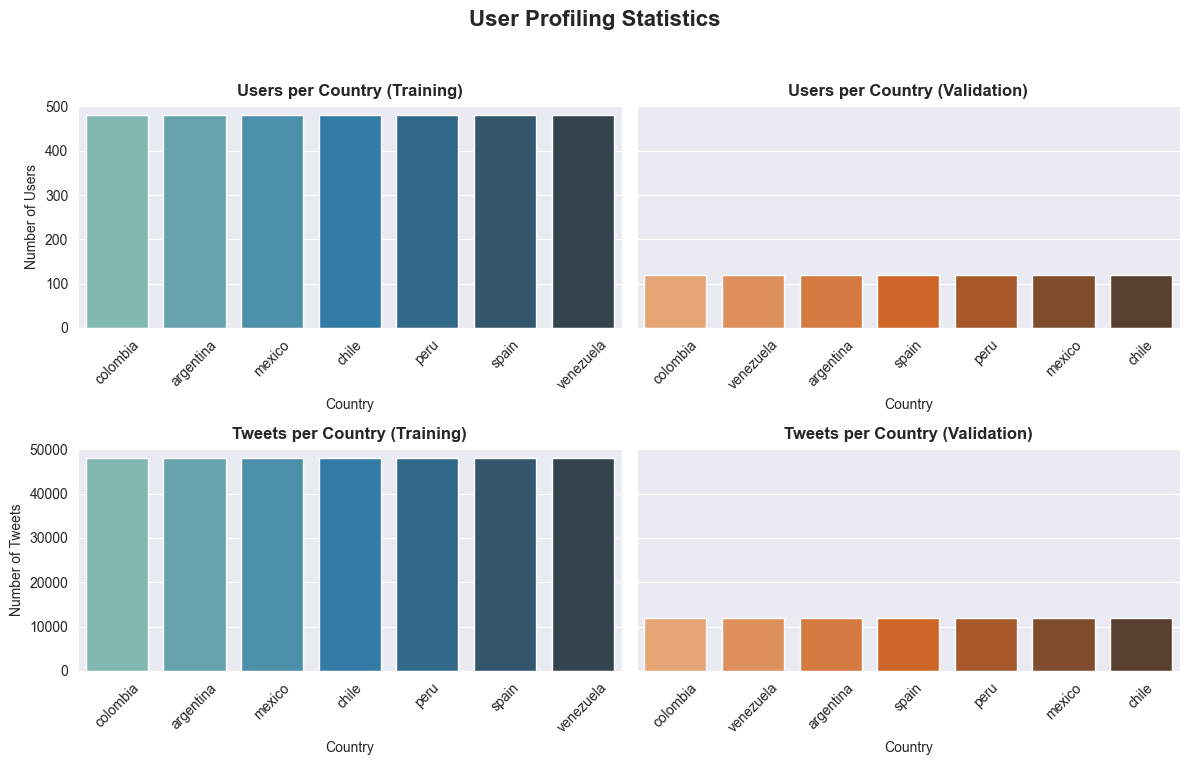

In [4]:
# Create a DataFrame for training and validation data.
df_train = pd.DataFrame(data_train, columns = ['user_id', 'text'], index = range(1, len(labels_train) + 1))
df_val   = pd.DataFrame(data_val, columns = ['user_id', 'text'], index = range(1, len(labels_val) + 1))
df_train['country'] = labels_train
df_val['country']   = labels_val

# Graphs for training and validation data.
fig, axs = plt.subplots(2, 2, figsize = (12, 8), sharey = 'row')
fig.suptitle('User Profiling Statistics', fontsize = 16, fontweight = 'bold')

# --- Graph 1: Users by country (training) ---
train_users_by_country = df_train[['user_id', 'country']].drop_duplicates()
sns.countplot(data = train_users_by_country, x = 'country', hue = 'country', ax = axs[0,0],
              palette = 'YlGnBu_d')
axs[0,0].set_title('Users per Country (Training)', fontsize = 12, weight = 'bold')
axs[0,0].set_xlabel('Country')
axs[0,0].set_ylabel('Number of Users')
axs[0,0].tick_params(axis = 'x', rotation = 45)

# --- Graph 2: Users by country (validation) ---
val_users_by_country = df_val[['user_id', 'country']].drop_duplicates()
sns.countplot(data = val_users_by_country, x = 'country', hue = 'country', ax = axs[0,1],
              palette = 'Oranges_d')
axs[0,1].set_title('Users per Country (Validation)', fontsize = 12, weight = 'bold')
axs[0,1].set_xlabel('Country')
axs[0,1].set_ylabel('')
axs[0,1].tick_params(axis = 'x', rotation = 45)

# --- Graph 3: Tweets by country (training) ---
sns.countplot(data = df_train, x = 'country', hue = 'country', ax = axs[1,0],
              palette = 'YlGnBu_d')
axs[1,0].set_title('Tweets per Country (Training)', fontsize = 12, weight = 'bold')
axs[1,0].set_xlabel('Country')
axs[1,0].set_ylabel('Number of Tweets')
axs[1,0].tick_params(axis = 'x', rotation = 45)

# --- Graph 4: Tweets by country (validation) ---
sns.countplot(data = df_val, x = 'country', hue = 'country', ax = axs[1,1],
              palette = 'Oranges_d')
axs[1,1].set_title('Tweets per Country (Validation)', fontsize = 12, weight = 'bold')
axs[1,1].set_xlabel('Country')
axs[1,1].set_ylabel('')
axs[1,1].tick_params(axis = 'x', rotation = 45)

# Ajustar el layout
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
plt.show()

# **2.- (40pts) Diseñe un clasificador con alguna RNN con atención en jerárquia (como en el paper adjunto) que codifique cada perfil de usuario con todos sus tweets y clasifique. El primer nivel intuitivamente recibe embeddings de palabras, el segundo nivel de atención modela los tweets. Preinicialice su red con los embeedings w2v proporcionados.**

> Para este problema de clasificación, codificamos las etiquetas por país en un diccionario y viceversa.

In [5]:
country_map = {country: idx for idx, country in enumerate(df_train["country"].unique())}
inv_country_map = {v: k for k, v in country_map.items()}
print("Country Map         :", country_map)
print("Inverse Country Map :", inv_country_map)

Country Map         : {'colombia': 0, 'argentina': 1, 'mexico': 2, 'chile': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}
Inverse Country Map : {0: 'colombia', 1: 'argentina', 2: 'mexico', 3: 'chile', 4: 'peru', 5: 'spain', 6: 'venezuela'}


>Usando la librería *Dataset*, se crea la clase *AuthorProfilingDataset* la cual recibe el corpus en crudo y los labels creados anteriormente y se usa una estructura bastante similar a la usada en el notebook de la escuela. Es opcional eliminar las stopwords y se añaden los diccionarios creados.
>
>- Se define el método estático *load_vocab_embeddings()*, el cual carga el vocabulario y sus vectores de palabras preentrenados desde el archivo 'word2vec_col.txt' y devuelve un diccionario que asigna cada palabra a un índice entero y una matriz donde cada fila es el vector de embeddings correspondiente al índice del vocabulario. Además, se agrega un vector de ceros para representar el padding ('pad') y un vector promedio de todos los embeddings para representar palabras desconocidas ('unk').
>
>- En *preprocessed_text()* se hace un preprocesamiento de los datos, se usa *TweetTokenizer()* en lugar de *word_tokenize()* como tokenizador default.
>
>- Se adaptaron los métodos *\_\_getitem\_\_()* y *collate_fn()* para manejar los labels en formato *('país')* en lugar de {0,1}, así como que cada instancia del dataset representa un usuario, que está asociado a una lista de tweets (documento) y una etiqueta (país), es decir, se maneja el dataset con respecto a usuarios, no a tweets como antes. Un ejemplo de su funcionamiento es: 
>
>**Entrada**: `(author_id, tweet)` → `"Me encanta programar"`
>
>⬇
>
>**Tokenización**  
>`['me', 'encanta', 'programar']` → `[17, 403, 92]`
>
>⬇
>
>**Agrupación por usuario:**  
>Cada usuario se representa como una lista de tweets, donde cada tweet es una lista de índices de palabras:
>
>```python
>[[17, 403, 92], [23, 5], ...]

In [6]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, corpus: Tuple[str, str], labels: List[str], country_map: dict = country_map,
                 tokenizer: Callable = None, remove_stopwords: bool = False, stopwords_set: set = stopwords_es):
        """
        Initialize the dataset.
        
        Parameters
        ----------
        corpus : Tuple[str, str]
            List of text data (tweets).
        labels : list[str]
            List of labels
        country_map : dict
            Dictionary that maps labels to their encoding.
        tokenizer : callable, optional
            Tokenizer for text processing. If None, a default tokenizer is used.
        remove_stopwords : bool, optional
            Whether to remove stopwords. Default is False.
        stopwords_set : set, optional
            Set of stopwords to be removed. Default is Spanish stopwords.
        """
        # Initialize.
        self.corpus = corpus
        self.labels = labels   
        self.country_map = country_map

        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords = stopwords_set

        # Initialize the user to tweets and labels.
        self.user_to_tweets = {}
        self.user_to_label = {}

        # Append the tweets and labels to the user.
        for (user_id, tweet), label in zip(corpus, labels):
            if user_id not in self.user_to_tweets:
                self.user_to_tweets[user_id] = []
                self.user_to_label[user_id] = label
            self.user_to_tweets[user_id].append(tweet)

        self.user_ids = list(self.user_to_tweets.keys())

        # Load the vocabulary and embeddings.
        self.vocab, self.emb_mat = AuthorProfilingDataset.load_vocab_embeddings()

    def __len__(self) -> int:
        """
        Return the number of users in the dataset.
        """
        return len(self.user_ids)

    @staticmethod
    def load_vocab_embeddings() -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings. It uses the word2vec model. The embeddings are
        stored in a file called 'word2vec_col.txt'.

        Returns
        -------
        vocab : dict
            A dictionary mapping words to their corresponding indices.
        emb_mat : np.ndarray
            A matrix of shape (vocab_size, embedding_dim) containing the word embeddings.
        """
        embeddings_list = []
        vocab = {}
        with open('word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector
        vocab['pad'] = 0
        vocab['unk'] = 1
        emb_mat = np.vstack(embeddings_list)
        
        return vocab, emb_mat
    
    def preprocessed_text(self, text: str) -> Tuple[List[str], List[int]]:
        """
        Preprocess the text. 

        Parameters
        ----------
        text : str
            The text to be preprocessed.
        
        Returns
        -------
        words : list
            List of words in the text.
        word_ids : list
            List of word IDs corresponding to the words in the text.
        """
        words = self.tokenizer.tokenize(text.lower())
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stopwords]
        word_ids = [self.vocab[word] if word in self.vocab else self.vocab['unk'] for word in words]

        return words, word_ids
    
    def __getitem__(self, index: int) -> Tuple[List[List[int]], int]:
        """
        Returns the processed data for a specific user.

        Parameters
        ----------
        index : int
            Index of the user within the dataset.

        Returns
        -------
        word_ids_list : List[List[int]]
            List of tweets from the user, where each tweet is a list of word IDs.
            Dimensions: [n_tweets, n_words_per_tweet]
    
        label_id : int
            Integer index corresponding to the user's country (according to country_map).
        """  
        user_id = self.user_ids[index]        # Get the user ID.
        tweets = self.user_to_tweets[user_id] # Get the tweets for the user.
        label = self.user_to_label[user_id]   # Get the label for the user.
        label_id = self.country_map[label]    # Get the label ID.

        word_ids_list = []
        for tweet in tweets:
            _, word_ids = self.preprocessed_text(tweet)
            word_ids_list.append(word_ids)

        return word_ids_list, label_id
    
    @staticmethod
    def collate_fn(batch: List[Tuple[List[int], int]]) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Collates a batch of user profiles into padded tensors suitable for hierarchical models.

        This function pads tweets to the same number of words (max_words), and profiles to the same number
        of tweets (max_tweets), resulting in a 3D tensor: [batch_size, max_tweets, max_words].

        Parameters
        ----------
        batch : List[Tuple[List[List[int]], int]]
            A list of samples, where each sample is a tuple containing:
                - A list of tweets (each tweet is a list of word indices).
                - A label (integer representing the country class).

        Returns
        -------
        padded_input : torch.Tensor
            A tensor of shape [batch_size, max_tweets, max_words] containing the padded tweet data for each user.

        label_tensor : torch.Tensor
            A tensor of shape [batch_size] containing the integer labels.
        """
        padded_batch, labels, pad_value = [], [], 0 # Initialize the padded batch and labels.
    
        # Get the maximum number of tweets and words in the batch.
        max_tweets = max(len(tweet_ids_list) for tweet_ids_list, _ in batch)
        max_words = max(len(word_ids) for tweet_ids_list, _ in batch for word_ids in tweet_ids_list)
    
        for tweet_ids_list, label in batch: # Iterate over the batch.
            tweet_tensors = []              # List to store the tweet tensors.
    
            for word_ids in tweet_ids_list:
                padding = [pad_value] * (max_words - len(word_ids))
                tweet_tensor = torch.tensor(word_ids + padding, dtype = torch.long)
                tweet_tensors.append(tweet_tensor)
    
            while len(tweet_tensors) < max_tweets:
                tweet_tensors.append(torch.zeros(max_words, dtype = torch.long))
    
            tweet_tensor = torch.stack(tweet_tensors) # Stack the tweet tensors.
            padded_batch.append(tweet_tensor)
            labels.append(label)
    
        padded_input = torch.stack(padded_batch) # Stack the padded batch.
        label_tensor = torch.tensor(labels)
    
        return padded_input, label_tensor

> Dado que ahora estamos haciendo esto a nivel de perfil de usuario en lugar de tweets (3360 vs. 335998), se eligió un tamaño de batch más pequeño ($8$). Se crean los datasets y dataloaders:

In [7]:
# Create the datasets.
train_dataset = AuthorProfilingDataset(data_train, labels_train, country_map = country_map)
val_dataset = AuthorProfilingDataset(data_val, labels_val, country_map = country_map)

# Create the dataloaders.
batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size = batch_size,
                              collate_fn = train_dataset.collate_fn, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size,
                            collate_fn = val_dataset.collate_fn, shuffle = False)

> Revisamos la estructura de los batchs se tiene que, para este ejemplo, cada batch tiene $8$ usuarios, cada uno con $100$ tweets, y cada tweet con alrededor de $35$ palabras:

In [8]:
batch = next(iter(train_dataloader))
print("Train batch shape :", batch[0].shape)
print("Labels shape      :", batch[1].shape)

Train batch shape : torch.Size([8, 100, 35])
Labels shape      : torch.Size([8])


> A continuación, se define la clase *Attention* de *nn.Module* que implementa el mecanismo de atención que se describe en el paper
> - Word-level attention (Eq. 5–7),
> - Sentence-level (tweet-level) attention (Eq. 8–10).
>
> Esto permite aprender qué partes de una secuencia son más importantes. Recibe una secuencia (como una serie de tweets codificados) y calcula:
> - Un peso de atención para cada elemento de la secuencia.
> - Una representación final ponderada, que es un resumen de la secuencia enfocándose más en los elementos relevantes.
>
>Se usa tanto a nivel de palabras (dentro de un tweet) como a nivel de tweets (dentro del perfil de usuario).
>
>Y la clase *HierarchicalAttentionNet* también de *nn.Module*. Aquí se implementa el modelo completo de Red de Atención Jerárquica y su objetivo es clasificar la nacionalidad del perfil de un usuario a partir de todos sus tweets. Se hace en dos niveles:
>    1.	Nivel palabra: convierte cada tweet en un vector usando una BiGRU y atención sobre las palabras más relevantes.
>	2.	Nivel tweet: convierte todos los tweets de un usuario en un solo vector usando otra BiGRU y atención sobre los tweets más importantes.
>
> Finalmente, ese vector se pasa a una capa lineal para hacer la clasificación del usuario.

In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        """
        Attention mechanism. Computes a context-aware weighted average of encoder outputs using a learned context
        vector using the following equations of the paper:
            - Word-level: Eq. (5)-(7)
            - Sentence-level: Eq. (8)-(10)

        Parameters
        ----------
        hidden_size : int
            Dimensionality of the encoder outputs.
        """
        super(Attention, self).__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)            
        self.context_vector = nn.Parameter(torch.randn(hidden_size)) 

    def forward(self, encoder_outputs: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute attention-weighted sum of encoder outputs.

        Parameters
        ----------
        encoder_outputs : torch.Tensor
            Tensor of shape [batch, seq_len, hidden_size] from a BiGRU.

        Returns
        -------
        weighted_output : torch.Tensor
            The weighted sum of encoder outputs, shape [batch, hidden_size].
        attention_weights : torch.Tensor
            Attention weights for each input element, shape [batch, seq_len].
        """
        u = torch.tanh(self.linear(encoder_outputs))  
        attention_scores = torch.matmul(u, self.context_vector)  
        attention_weights = F.softmax(attention_scores, dim = 1) 
        weighted_output = torch.sum(encoder_outputs * attention_weights.unsqueeze(-1), dim = 1) 
        return weighted_output, attention_weights

class HierarchicalAttentionNet(nn.Module):
    """
    Hierarchical Attention Network for Author Profiling. This model uses a two-level attention mechanism to
    process tweets from users. The first level applies attention to the words in each tweet, and the second
    level applies attention to the tweets of each user. The final output is a classification of the user into
    one of the countries. Architecture components:
        - Word-level BiGRU + attention (per tweet) — Eq. (1)-(7)
        - Tweet-level BiGRU + attention (per user) — Eq. (1)-(10)
        - Final classifier — Eq. (11)

    Parameters
    ----------
    emb_dim : int
        Dimensionality of word embeddings.
    word_hidden_size : int
        Hidden size of the word-level GRU (per direction).
    tweet_hidden_size : int
        Hidden size of the tweet-level GRU (per direction).
    num_classes : int
        Number of output classes (e.g., countries).
    emb_matrix : np.ndarray
        Pretrained embedding matrix to initialize the embedding layer.
    """
    def __init__(self, emb_dim: int, word_hidden_size: int, tweet_hidden_size: int, num_classes: int,
                 emb_matrix: np.ndarray):
        super().__init__()

        # Embedding layer using pretrained word2vec.
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype = torch.float32),
            freeze = False # Set to True if you want to freeze the embeddings.
        )

        # Word-level BiGRU encoder (per tweet).
        self.word_gru     = nn.GRU(
            input_size    = emb_dim,
            hidden_size   = word_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Word-level attention.
        self.word_attention = Attention(2 * word_hidden_size)

        # Tweet-level BiGRU encoder (per user).
        self.tweet_gru    = nn.GRU(
            input_size    = 2 * word_hidden_size,
            hidden_size   = tweet_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Tweet-level attention.
        self.tweet_attention = Attention(2 * tweet_hidden_size)

        # Final classifier.
        self.classifier = nn.Linear(2 * tweet_hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the Hierarchical Attention Network.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape [batch_size, max_tweets, max_words], where each entry is a word index.

        Returns
        -------
        logits : torch.Tensor
            Output tensor of shape [batch_size, num_classes], containing raw scores for each class.
        """
        batch_size, num_tweets, num_words = x.size()

        # Flatten batch and tweets to process all tweets in parallel
        x = x.view(-1, num_words) 
        x = self.embedding(x)      

        word_output, _ = self.word_gru(x)                                              # Encode words using BiGRU.
        tweet_representations, word_attn_weights = self.word_attention(word_output)    # Word-level attention to get tweet representation.
        tweet_representations = tweet_representations.view(batch_size, num_tweets, -1) # Reshape.
        tweet_output, _ = self.tweet_gru(tweet_representations)                        # Encode tweets using BiGRU.
        doc_representation, tweet_attn_weights = self.tweet_attention(tweet_output)    # Tweet-level attention to get user/document representation

        # Apply the classifier.
        logits = self.classifier(doc_representation)

        return logits, word_attn_weights, tweet_attn_weights


> Para la parte de entrenamiento y evaluación del modelo entrenado, se definen las clases:
>
> **1. Trainer:**
>
> En esta clase se describe todo el proceso de entrenamiento para un modelo dado en *nn.Module*. Recibe las épocas a entrenar, los parámetros del optimizador: se eligió *Adam* con parámetros $\beta$ = (0.9, 0.999), regularización $L_2$ vía *weight decay*, y control del learning rate mediante el scheduler *ReduceLROnPlateau* (modo 'min', con patience y factor configurables). El proceso de entrenamiento realiza *early stopping* basado en el puntaje *F1* de la tarea de validación. Se guardan checkpoints automáticos del modelo y del mejor modelo, y permite visualizar las métricas de entrenamiento mediante gráficos.
>
> La función de pérdida utilizada, *nn.CrossEntropyLoss()*, es la elección estándar para tareas de clasificación multiclase, ya que combina softmax con log-loss para penalizar con mayor fuerza las predicciones incorrectas. La elección de *F1-score* como métrica es adecuada por ser un problema multitarea de clasificación, ya que permite balancear precisión y recall. Se emplea *F1-score (macro)* ya que se tienen clases balanceadas.
>
> **NOTA:** La elección del optimizador y demás hiperparámetros es la misma que en el notebook de la clase y dieron buenos resultados.

In [10]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, lr: float, patience: int = 3,
            weight_decay: float = 1e-4, betas: Tuple[float, float] = (0.9, 0.999),
            lr_patience: int = 3, lr_factor: float = 0.1, checkpoint_path: str = 'trained_model',
            checkpoint_filename: str = 'checkpoint.pth', best_model_filename: str = 'best_model.pth'
    ):
        """
        Initialize the Trainer class.
        
        Parameters
        ----------
        model : nn.Module
            The model to be trained.
        epochs : int
            Number of epochs for training.
        train_dataset : Dataset
            The training dataset.
        train_dataloader : DataLoader
            DataLoader for the training dataset.
        val_dataloader : DataLoader
            DataLoader for the validation dataset.
        device : str
            The device to be used for training (CPU or GPU).
        lr : float, optional
            Learning rate for the optimizer. Default is 1e-3.
        patience : int, optional
            Number of epochs with no improvement after which training will be stopped. Default is 3.
        weight_decay : float, optional
            Weight decay for the optimizer. Default is 1e-4.
        betas : tuple, optional
            Betas for the optimizer. Default is (0.9, 0.999).
        lr_patience : int, optional
            Number of epochs with no improvement after which learning rate will be reduced. Default is 3.
        lr_factor : float, optional
            Factor by which the learning rate will be reduced. Default is 0.1.
        checkpoint_path : str, optional
            Path to save the checkpoint. Default is 'trained_model'.
        checkpoint_filename : str, optional
            Filename for the checkpoint. Default is 'checkpoint.pth'.
        best_model_filename : str, optional
            Filename for the best model. Default is 'best_model.pth'.
        """
        # Initialize the trainer.
        self.model = model.to(device)
        self.epochs = epochs
        self.train_dataset = train_dataset
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.patience = patience

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path
        self.checkpoint_filename = checkpoint_filename
        self.best_model_filename = best_model_filename

        # Training metadata.
        self.train_loss_history = []   # Training loss history.
        self.val_loss_history   = []   # Validation loss history.
        self.f1_history         = []   # f1 metric history for country.
        self.best_val_f1        = 0    # Best f1 metric in validation set.
        self.n_no_improvement   = 0    # Number of epochs without improvement.
        self.best_state_dict    = None # Store the best model state dict.

        # Optimizer.
        self.optimizer   = optim.Adam(           
            params       = model.parameters(), # parameters to optimize.
            lr           = lr,                 # learning rate.
            weight_decay = weight_decay,       # weight decay.
            betas        = betas               # betas for the optimizer.
        )

        # Scheduler.
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau( 
            optimizer  = self.optimizer, # optimizer to adjust.
            mode       = 'min',          # mode (min means reduce when the quantity monitored has stopped decreasing).
            patience   = lr_patience,    # patience (number of epochs with no improvement after which learning rate will be reduced).
            factor     = lr_factor       # factor by which the learning rate will be reduced. new_lr = lr * factor.
        )

        # Loss function for classification.
        self.criterion = nn.CrossEntropyLoss()

    def eval_model(self, dataloader: DataLoader) -> dict:
        """
        Evaluates the multitask model.

        Parameters
        ----------
        dataloader : DataLoader
            DataLoader for the evaluation dataset.

        Returns
        -------
        dict
            Dictionary containing the loss, f1 score, scores, predictions and targets.
        """
        with torch.no_grad():
            self.model.eval() # Set the model to evaluation mode.
            
            losses = []                         # List to store the losses.
            preds, targets, scores = [], [], [] # List to store the predictions, targets and scores for country.
    
            # Iterate over the batches.
            for inputs, labels in tqdm(dataloader, desc = 'Evaluation... ', colour = 'blue'):
                torch.cuda.empty_cache() # Clear the cache.
                inputs, labels = inputs.to(self.device), labels.to(self.device)
    
                # Forward pass.
                logits, _, _ = self.model(inputs) # Output of the model.

                # Calculate the loss for the batch.
                loss_per_batch = self.criterion(logits, labels)
                losses.append(loss_per_batch.item())

                # Predictions and targets.
                pred = logits.argmax(dim = 1) # Predicted class for country

                # Append predictions and true labels to the lists.
                preds += pred.cpu().tolist()
                targets += labels.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs = torch.softmax(logits, dim = 1)
                scores += probs[torch.arange(len(pred)), pred].cpu().tolist()

            # F1 scores
            f1 = f1_score(targets, preds, average = 'macro') # For multi-class classification.

            return {
                'loss'    : np.mean(losses),
                'f1'      : f1,
                'scores'  : scores,
                'preds'   : preds,
                'targets' : targets,
                }

    def train(self):
        """
        Train the model.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            loss_train = 0
            epoch_time = time.time() # Start time of the epoch.
    
            for inputs, labels in tqdm(self.train_dataloader, desc = 'Training... ', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.       
                self.optimizer.zero_grad() # Zero the gradients.
    
                inputs, labels = inputs.to(self.device), labels.to(self.device)
    
                logits, _, _ = self.model(inputs) # Forward pass.
    
                # Calculate the loss for the batch.
                loss_per_batch = self.criterion(logits, labels)
    
                # Backward pass and optimization.
                loss_per_batch.backward()
                self.optimizer.step()
                loss_train += loss_per_batch.item()
    
            # Average loss for the epoch.
            loss_train /= len(self.train_dataloader)
    
            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)
            val_loss    = val_results['loss']
            val_f1      = val_results['f1']

            # Store the results.
            self.train_loss_history.append(loss_train)
            self.val_loss_history.append(val_loss)
            self.f1_history.append(val_f1)
    
            # Sum of F1 scores to determine the best model.
            is_improvement = val_f1 > self.best_val_f1
            
            if is_improvement:
                self.best_val_f1 = val_f1
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state = {
                    # This epoch information.
                    'epoch'              : epoch,
                    'state_dict'         : self.model.state_dict(),
                    'loss_train'         : loss_train,
                    'loss_val'           : val_loss,
                    'elapsed_time'       : elapsed_time,
                    # Best information.
                    'best_val_f1'        : self.best_val_f1,
                    'best_epoch'         : self.best_epoch,
                    'best_time'          : self.best_time,
                    # History information.
                    'train_loss_history' : self.train_loss_history,
                    'val_loss_history'   : self.val_loss_history,
                    'f1_history'         : self.f1_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL}")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break
    
            # Print the results.
            tqdm.write(f"{Style.BRIGHT}{Fore.CYAN} Epoch{epoch:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Training loss: {Fore.GREEN}{loss_train:.6f}{Style.RESET_ALL} | "
                       f"Validation Loss: {Fore.YELLOW}{val_loss:.6f}{Style.RESET_ALL} | "
                       f"F1: {Fore.MAGENTA}{val_f1:.6f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Save a checkpoint of the model, including the state dictionary, training metadata,
        optimizer state, and the initialization parameters used to construct the model.

        Parameters
        ----------
        state : dict
            Dictionary with the model state, best model state, loss histories, and optimizer state.
        is_best : bool
            If True, also save the model as the best checkpoint.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict()}, best_path)

    def plot_metrics(self):
        """
        Plot the training and validation loss and F1 score over epochs.
        """
        epochs = list(range(1, len(self.train_loss_history) + 1))
    
        fig, axes = plt.subplots(1, 2, figsize = (16,6)) 
    
        # Loss plot.
        axes[0].plot(epochs, self.train_loss_history, label = 'Training Loss', color = '#1f77b4')
        axes[0].plot(epochs, self.val_loss_history, label = 'Validation Loss', color = '#ff7f0e')
        axes[0].axvline(self.best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {self.best_epoch}")
        axes[0].set_title('Loss over Epochs', fontsize = 14, fontweight = 'bold')
        axes[0].set_xlabel('Epochs', fontsize = 12)
        axes[0].set_ylabel('Loss', fontsize = 12)
        axes[0].legend(fontsize = 12)
        axes[0].grid(True)
    
        # F1 Score plot.
        axes[1].plot(epochs, self.f1_history, label = 'F1', color = '#d62728')
        axes[1].axvline(self.best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {self.best_epoch}")
        axes[1].set_title('F1 Score over Epochs', fontsize = 14, fontweight = 'bold')
        axes[1].set_xlabel('Epochs', fontsize = 12)
        axes[1].set_ylabel('F1 Score', fontsize = 12)
        axes[1].legend(fontsize = 12)
        axes[1].grid(True)
    
        plt.tight_layout()
        plt.show()

> **2. Evaluation:**
>
> Se usa para evaluar los modelos de clasificación entrenados. Se calculan métricas de desempeño como pérdida promedio y puntaje *F1* tanto en los conjuntos de entrenamiento como validación, se generan reportes por clase usando *classification_report*, y se visualizan los resultados mediante matrices de confusión; la clase asume que el modelo implementado por el Trainer devuelve logits y que la evaluación se hace por medio del método *eval_model*, reutilizando la lógica de entrenamiento y evaluación configurada.

In [11]:
class Evaluation:

    @staticmethod
    def plot_confusion_matrix(y_true: List[int], y_pred: List[int], labels: List[str]) -> None:
        """
        Display side-by-side confusion matrices for gender and country classification.

        Parameters
        ----------
        y_true : list or array
            True country labels.
        y_pred : list or array
            Predicted country labels.
        labels : list of str
            Class names for country.
        """
        fig, ax = plt.subplots(figsize = (7, 5))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples',
                    xticklabels = labels, yticklabels = labels, ax = ax)
        ax.set_title("Confusion Matrix", fontsize = 16, fontweight = 'bold')
        ax.set_xlabel("Predicted Label", fontsize = 12)
        ax.set_ylabel("True Label", fontsize = 12)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def evaluate_best_model(trainer: Trainer, train_dataloader: DataLoader, val_dataloader: DataLoader,
                            filename: str = "trained_model/best_model.pth") -> Tuple[dict, dict]:
        """
        Evaluate the best trainer on the training and validation sets.

        Parameters
        ----------
        train_dataloader : DataLoader
            DataLoader for the training set.
        val_dataloader : DataLoader
            DataLoader for the validation set.
        results : bool, optional
            Whether to return the results. Default is True.
        
        Returns
        -------
        train_results : dict
            Dictionary containing the training results.
        val_results : dict
            Dictionary containing the validation results.
        """
        checkpoint = torch.load(filename, map_location = 'cpu', weights_only = True)
        trainer.model.load_state_dict(checkpoint['best_model_state_dict'])      
        trainer.model.eval() # Set the trainer to evaluation mode.
        
        print("\nEvaluando en conjunto de entrenamiento:")
        train_results = trainer.eval_model(train_dataloader)
        train_loss    = train_results['loss']
        f1_train      = train_results['f1']

        print("\nEvaluando en conjunto de validación:")
        val_results = trainer.eval_model(val_dataloader)
        val_loss    = val_results['loss']
        f1_val      = val_results['f1']

        print(f"\nTrain Loss : {train_loss:.4f} | F1 : {f1_train:.4f}")
        print(f"Val Loss   : {val_loss:.4f} | F1 : {f1_val:.4f}")
    
        incorrect = sum(t != p for t, p in zip(val_results['targets'], val_results['preds']))
        total     = len(val_results['targets'])
        print(f"\nNúmero de errores en validación: {incorrect} de {total} muestras")

        # Labels for the results.
        labels = [label for label, idx in sorted(trainer.train_dataset.country_map.items(), key = lambda x: x[1])]

        print("\nPer-class report:")
        print(classification_report(val_results['targets'], val_results['preds'], target_names = labels))

        # Plot the confusion matrices
        Evaluation.plot_confusion_matrix(
            val_results['targets'], val_results['preds'], labels
        )

        return train_results, val_results

> **Entrenamiento:**
>
> A continuación de definen los parámetros necesarios para entrenar el modelo, se crean las instancias y se entrena por 10 épocas.
>
> **NOTA:** La elección del optimizador y demás hiperparámetros es la misma que en el notebook de la clase y dieron buenos resultados.

Evaluation... : 100%|██████████| 105/105 [00:07<00:00, 13.51it/s]


 Epoch  1/10  ➤ Training loss: 1.825947 | Validation Loss: 1.482811 | F1: 0.490213 | Epoch Time: 126.00 s | Total Time: 124.99 s


Evaluation... : 100%|██████████| 105/105 [00:07<00:00, 13.22it/s]


 Epoch  2/10  ➤ Training loss: 1.074323 | Validation Loss: 0.905049 | F1: 0.733658 | Epoch Time: 118.56 s | Total Time: 243.83 s


Evaluation... : 100%|██████████| 105/105 [00:07<00:00, 14.05it/s]


...

 Epoch  8/10  ➤ Training loss: 0.189872 | Validation Loss: 0.519782 | F1: 0.855573 | Epoch Time: 120.74 s | Total Time: 967.99 s


Evaluation... : 100%|██████████| 105/105 [00:07<00:00, 13.18it/s]


 Epoch  9/10  ➤ Training loss: 0.134931 | Validation Loss: 0.494733 | F1: 0.860357 | Epoch Time: 121.87 s | Total Time: 1089.98 s


Evaluation... : 100%|██████████| 105/105 [00:07<00:00, 13.48it/s]


 Epoch 10/10  ➤ Training loss: 0.103612 | Validation Loss: 0.528190 | F1: 0.859302 | Epoch Time: 120.62 s | Total Time: 1211.02 s

--- Total Training Time: 1211.02 seconds ---


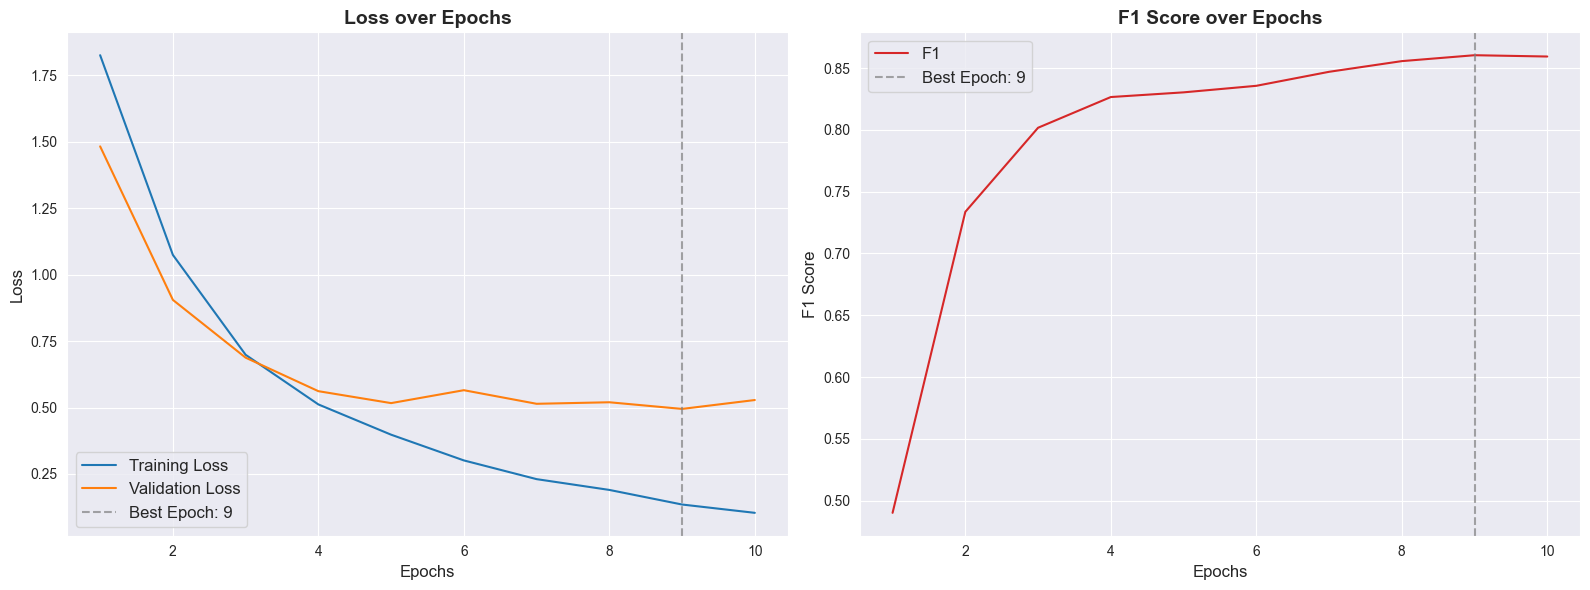

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Parameters for the Hierarchical Attention Network (HAN).
params_HAN = {
    'emb_dim'           : 100,
    'word_hidden_size'  : 50,
    'tweet_hidden_size' : 50,
    'num_classes'       : len(country_map),
    'emb_matrix'        : train_dataset.emb_mat
}

# Parameters for the trainer.
params_train_HAN = {
    'epochs'              : 10,
    'train_dataset'       : train_dataset,
    'train_dataloader'    : train_dataloader,
    'val_dataloader'      : val_dataloader,
    'device'              : device,
    'lr'                  : 1e-3,
    'patience'            : 3,
    'weight_decay'        : 1e-4,
    'betas'               : (0., 0.999),
    'lr_patience'         : 3,
    'lr_factor'           : 0.1,
    'checkpoint_filename' : 'HAN_checkpoint.pth',
    'best_model_filename' : 'best_HAN_model.pth'
}

# Create the model.
model_HAN = HierarchicalAttentionNet(**params_HAN).to(device)

# Create the trainer.
trainer_HAN = Trainer(model = model_HAN, **params_train_HAN)

# Train the model.
trainer_HAN.train()

# Plot the training and validation loss and F1 score.
trainer_HAN.plot_metrics()

> Una vez terminado, se pasa por el proceso de evaluación y imprimen los resultados más relevantes:


Evaluando en conjunto de entrenamiento:


Evaluation... : 100%|██████████| 420/420 [00:32<00:00, 12.97it/s]



Evaluando en conjunto de validación:


Evaluation... : 100%|██████████| 105/105 [00:08<00:00, 13.00it/s]


Train Loss : 0.0671 | F1 : 0.9825
Val Loss   : 0.4947 | F1 : 0.8604

Número de errores en validación: 117 de 840 muestras

Per-class report:
              precision    recall  f1-score   support

    colombia       0.86      0.85      0.85       120
   argentina       0.88      0.95      0.92       120
      mexico       0.90      0.82      0.86       120
       chile       0.89      0.91      0.90       120
        peru       0.80      0.86      0.83       120
       spain       0.85      0.83      0.84       120
   venezuela       0.86      0.81      0.83       120

    accuracy                           0.86       840
   macro avg       0.86      0.86      0.86       840
weighted avg       0.86      0.86      0.86       840



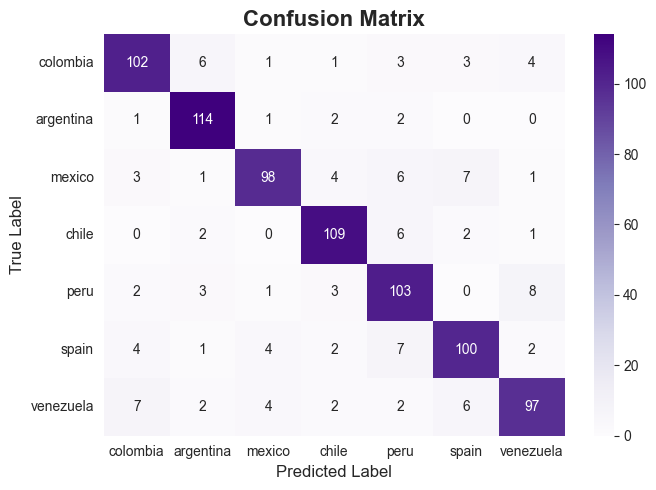

In [13]:
# Evaluate the best model on the training and validation sets.
train_results_RNN, val_results_RNN = Evaluation.evaluate_best_model(
    trainer_HAN, train_dataloader, val_dataloader, filename = "trained_model/best_HAN_model.pth")

# **5.- (30pts) Discuta brevemente el rendimiento del modelo anterior. Para el punto anterior, construya algunas visualizaciones como en la Figura 6 del paper de atención jerárquica y discuta.**

> **DISCUSIÓN:**
>
>A diferencia de los ejemplos vistos en el notebook en la escuela, aquí se notó un crecimiento muy grande en la eficiencia y en el aprendizaje ya que en tan solo 10 épocas hubo un score f1 de $0.8604$ y pérdidas de $0.0671$ para el conjunto de entrenamiento y $0.4947$ para el de validación. Así como $117$ predicciones erróneas de $840$ posibles. Esto hace mucho sentido ya que el problema en este caso es bastante similar al del paper, solo que en lugar de documentos con oraciones, se están usando perfiles con tweets, lo cual es una analogía perfecta.
>
> **Visualización:**
>
> Esto permite visualizar e interpretar cómo el modelo HAN toma decisiones para clasificar usuarios según sus tweets. Se define la función *colorize()* como en el notebook de la escuela: toma una lista de palabras y sus pesos de atención, y devuelve una representación donde cada palabra es coloreada según su relevancia en la predicción. Luego, la función *visualize_user_attention()* se encarga de procesar un usuario específico del conjunto de validación: extrae sus tweets, obtiene las atenciones a nivel palabra y tweet a través del modelo entrenado, y muestra los tweets con mayor peso en la decisión del modelo.
>
> Finalmente, se seleccionan cinco usuarios aleatorios del conjunto de validación y se aplica esta visualización a cada uno.

In [14]:
def colorize(words: List[str], attn: np.ndarray) -> str:
    """
    Colorize a list of words using a colormap based on attention values.

    Parameters
    ----------
    words : list of str
        The tokenized words in a tweet or sentence.
    attn : np.ndarray
        Attention weights for each word, values between 0 and 1.

    Returns
    -------
    html_str : str
        HTML-formatted string with background color applied.
    """
    cmap = mpl.colormaps.get_cmap('Purples')
    template = '<span class="barcode"; style="color: black; background-color: {}">{}</span>'
    colored_string = ''
    for word, score in zip(words, attn):
        color = mpl.colors.rgb2hex(cmap(score)[:3])
        colored_string += template.format(color, '&nbsp;' + word + '&nbsp;')
    return colored_string

def visualize_user_attention(model: nn.Module, dataset: Dataset, idx: int, n_tweets: int, label_map: dict):
    """
    Visualizes attention over tweets and words for a given user index.

    Parameters
    ----------
    model : nn.Module
        Trained HierarchicalAttentionNet.
    dataset : Dataset
        The dataset used (must contain .tokenizer, .user_to_tweets, .user_ids).
    idx : int
        Index of the user in the dataset.
    n_tweets : int
        Number of tweets to display.
    label_map : dict or None
        Optional map from class indices to label names.
    """
    model.eval()

    # Get user input (list of tweets as list of word_ids) and label
    input_tensor, label = dataset[idx]
    batch = dataset.collate_fn([(input_tensor, label)])
    input_tensor = batch[0]

    with torch.no_grad():
        logits, word_attns, tweet_attns = model(input_tensor)

    pred = logits.argmax(dim = 1).item()

    # Recover raw tweets and user ID
    user_id   = dataset.user_ids[idx]
    tweets    = dataset.user_to_tweets[user_id]
    tokenizer = dataset.tokenizer

    # Display label info
    label_name = label_map[label] if label_map else str(label)
    pred_name  = label_map[pred] if label_map else str(pred)
    print("-" * 80)
    print(f"País real: {label_name} | Predicho: {pred_name}")
    print("-" * 80)

    tweet_attns = tweet_attns[0].cpu().numpy()               # Convert tweet-level attention to numpy
    tweet_indices = np.argsort(tweet_attns)[::-1][:n_tweets] # Sort tweets by attention weight (optional)

    for i in tweet_indices:
        words = tokenizer.tokenize(tweets[i])
        word_attn = word_attns[i].cpu().numpy()
        print(f"Tweet {i+1} - Atención: {tweet_attns[i]:.3f}")
        html = colorize(words[:len(word_attn)], word_attn)
        display(HTML(html), display_id = f"tweet_{i}")

In [15]:
for i in np.random.choice(len(val_dataset), 5, replace = False):
    visualize_user_attention(model_HAN, val_dataset, idx = i, label_map = inv_country_map, n_tweets = 3)

--------------------------------------------------------------------------------
País real: venezuela | Predicho: venezuela
--------------------------------------------------------------------------------
Tweet 99 - Atención: 0.205


Tweet 92 - Atención: 0.171


Tweet 48 - Atención: 0.169


--------------------------------------------------------------------------------
País real: colombia | Predicho: colombia
--------------------------------------------------------------------------------
Tweet 2 - Atención: 0.251


Tweet 99 - Atención: 0.157


...

Tweet 18 - Atención: 0.211


Tweet 50 - Atención: 0.169


--------------------------------------------------------------------------------
País real: spain | Predicho: spain
--------------------------------------------------------------------------------
Tweet 23 - Atención: 0.939


Tweet 13 - Atención: 0.061


Tweet 34 - Atención: 0.000


> Podemos ver que la mayoría de las palabras que reciben más atención para clasificar el país son nombres de ciudades o estados de dichos países.

# **6.- (20pts) Conteste lo siguiente MUY brevemente:**

### **6.1.- ¿Qué representación de términos uso el profesor para participar? http://ceur-ws.org/Vol-1866/paper_109.pdf**

> La representación utilizada fue una combinación de representaciones usuales y una llamada User Specific Representation (USR). En particular, se evaluaron tres enfoques principales:
> 1. Bolsa de palabras con pesos *TF-IDF*.
> 2. Word2Vec (W2V), y los vectores de cada palabra se promedian para representar cada documento.
> 3. User Specific Representation (USR), donde cada palabra se representa según su distribución en todos los documentos de usuarios.
>
>En el caso de USR, se parte de la hipótesis de que los términos comparten significado si aparecen en documentos de usuarios similares (parecida a la hipótesis distribucional), y se aprovecha esto para enriquecer la representación de cada documento. 

### **6.2.- ¿Qué usó el primer lugar de la competencia? (Basile, et al.) (Consulte: http://ceur-ws.org/Vol-1866/)**

>El sistema que obtuvo el primer lugar fue N-GrAM. Su enfoque se basó en un clasificador *SVM* lineal utilizando *n-gramas de palabras* (unigramas y bigramas) y *n-gramas de caracteres* (de 3 a 5 caracteres), todos ponderados con TF-IDF.

### **6.3.- ¿Cuántos y que competidores usaron deep learning? En una o dos oraciones escriba qué hicieron: https://ceur-ws.org/Vol-1866/**

>$6$ equipos utilizaron enfoques de deep learning. Estos fueron:
> 1. **Author Masking using Sequence-to-Sequence Models:** usaron un modelo Encoder-Decoder basado en LSTM para generar versiones parafraseadas de oraciones originales, con el objetivo de modificar el estilo del autor sin alterar el significado.
> 2. **Subword-based Deep Averaging Networks for Author Profiling in Social Media:** utilizaron Deep Averaging Networks (DAN), una red neuronal simple que promedia embeddings de palabras a partir de subword character n-grams generados con FastText.
> 3. **Author Profiling with Bidirectional RNNs using Attention with GRUs:** propusieron una red neuronal basada en bidirectional RNN con un mecanismo de atención para clasificar tweets por género y variedad lingüística. Entrenaron el modelo con embeddings preentrenados, y agregaron predicciones a nivel tweet para obtener la del autor (como nosotros en esta tarea).
> 4. **Author Profiling with Word+Character Neural Attention Network:** propusieron dos modelos con arquitectura híbrida que combinan embeddings de palabras y caracteres, una Bi-GRU, CNN y un mecanismo de atención jerárquico, fusionando la información a nivel tweet y a nivel usuario.
> 5. **UniNE at CLEF 2017: TF-IDF and Deep-Learning for Author Profiling:** utilizaron un modelo CNN alimentado con una matriz de ratios de 2-gramas de letras, signos de puntuación y características estructurales.
> 6. **Convolutional Neural Networks for Author Profiling Notebook for PAN at CLEF 2017:** utilizaron una red neuronal convolucional con múltiples filtros aplicados sobre secuencias de embeddings de palabras.

# **7.- (10pts) extra (Máxima Calificación 110%) para esta tarea: haga una comparación que muestre si la atención en jerarquía es útil vs no tenerla (e.g., sin atención o tener un solo nivel de atención)**

> Ups.